Spaceship Titanic
===

- 손상된 우주선 컴퓨터 시스템에서 복구된 기록을 사용하여 어떤 승객들이 이상 현상에 의해 이송되었는지 예측해야 합니다.

#### 파일 및 데이터 필드 설명

- train.csv - 전체 승객의 약 3분의 2(약 8700명)에 대한 개인 기록으로, 학습 데이터로 사용될 예정입니다.
- PassengerId- 각 승객에게는 고유 ID가 부여됩니다. 각 ID는 <그룹 번호> 형식으로 되어 있으며, < gggg_pp그룹 번호 gggg>는 승객이 속한 그룹을 나타내고 < pp그룹 내 번호>는 그룹 내 승객의 순번입니다. 그룹 구성원은 대개 가족이지만 항상 그런 것은 아닙니다.
- HomePlanet- 승객이 출발한 행성, 일반적으로는 영구 거주지 행성.
- CryoSleep- 승객이 항해 기간 동안 동면 상태에 들어가는 것을 선택했는지 여부를 나타냅니다. 동면 상태에 들어간 승객은 객실에 격리됩니다.
- Cabin- 승객이 투숙하는 객실 번호입니다. 형식은 이며 deck/num/side, 는 side좌현 P( Port) 또는 S우현 (Starboard)을 나타냅니다 .
- Destination- 승객이 하선할 행성.
- Age- 승객의 나이.
- VIP- 승객이 항해 중 특별 VIP 서비스를 유료로 이용했는지 여부.
- RoomService- 승객이 타이타닉FoodCourt 호의 다양한 고급 편의시설 ShoppingMall각각 에서 지불한 금액 Spa.VRDeck
- Name- 승객의 이름(성 및 이름).
- Transported- 승객이 다른 차원으로 이동했는지 여부. 이것이 바로 예측하려는 목표, 즉 핵심 변수입니다.
- test.csv - 나머지 3분의 1(약 4300명) 승객의 개인 기록이 포함된 테스트 데이터입니다. 여러분의 과제는 Transported이 데이터 세트에 속한 승객들의 값을 예측하는 것입니다.
- sample_submission.csv - 올바른 형식의 제출 파일입니다.
- PassengerId- 테스트 세트에 포함된 각 승객의 ID입니다.
- Transported- 목표. 각 승객에 대해 또는 를 예측 True합니다 False.

## 목차
0. install
1. 데이터와 도구 불러오기
2. EDA: 탐색적 데이터 분석
3. 전처리, 피처 엔지니어링
4. Modeling & 튜닝
5. 평가(Evaluation) 및 피처 중요도
6. Test & Submission
7. 마무리

### 0. install

In [1]:
!pip install lightgbm

### 1. 데이터와 도구 불러오기

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import os
from os.path import join

import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV

In [3]:
data_dir = './data'
data = pd.read_csv(join(data_dir, 'train.csv'))
data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [4]:
data.info() # 데이터의 총 개수, 빈칸(결측치) 유무, 글자(object)인지 숫자(int/float)인지 확인하는 명세서

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [5]:
data.describe() # 수치형 데이터들의 평균, 최대/최소값 등을 보여줌

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [6]:
data.isna().sum() # 컬럼별로 구멍(결측치)이 정확히 몇 개씩 뚫려있는지 카운트

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

### 2. EDA: 탐색적 데이터 분석

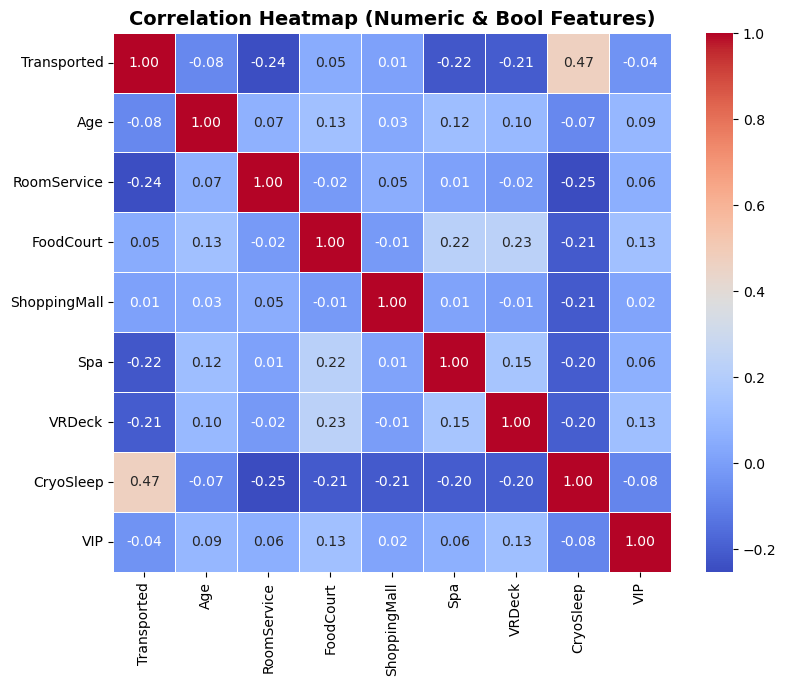

In [7]:
# 상관계수 확인, 숫자 변수들끼리 얼마나 친한가
plt.figure(figsize=(9, 7))

# 숫자형 변수들만 선별, 글자 데이터는 상관계수(수학적 비례 관계)를 계산할 수 없기 때문
numeric_features = ['Transported', 'Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'CryoSleep', 'VIP']

# .corr() 함수를 써서 변수들 간의 상관계수(-1 ~ 1)를 구함 
# Transported와 상관계수가 높을수록 정답을 맞추는 데 중요한 핵심 변수라는 뜻
correlation_matrix = data[numeric_features].astype(float).corr()

# 히트맵, 글자가 겹치지 않도록 소수점 둘째자리까지 표시
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap (Numeric & Bool Features)', fontweight='bold', fontsize=14)
plt.show()

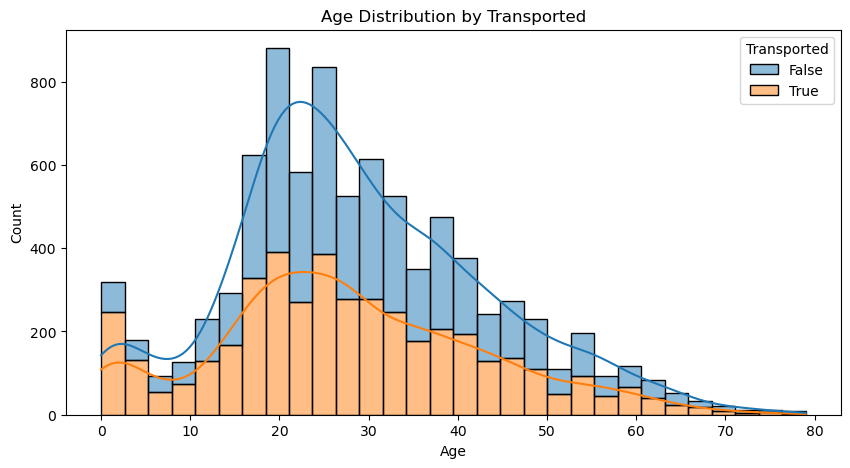

In [8]:
# 나이(Age)와 수송 여부(Transported)의 관계 그래프
plt.figure(figsize=(10, 5))
# hue='Transported'를 주어,
# 수송된 사람과 안 된 사람의 나이 분포를 다른 색으로 겹쳐 그림(stack)
# 결과 확인: 0~10세 어린아이들의 수송 비율이 높음
sns.histplot(data=data, x='Age', hue='Transported', kde=True, bins=30, multiple='stack')
plt.title('Age Distribution by Transported')
plt.show()

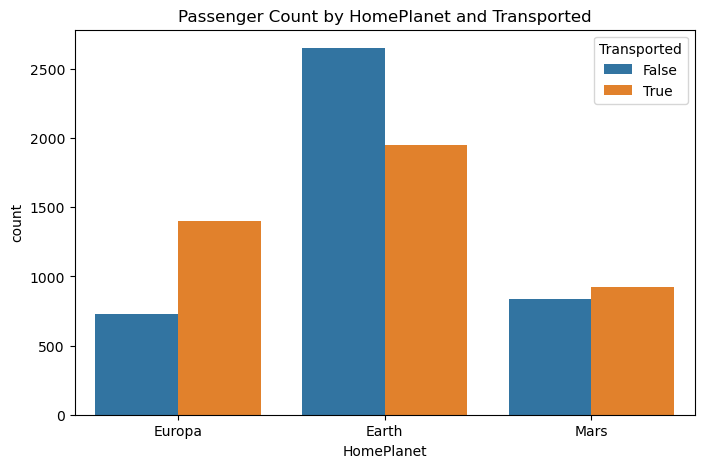

In [9]:
# 출발 행성(HomePlanet)에 따른 수송 여부
plt.figure(figsize=(8, 5))
# 출발 행성별로 수송된 사람/안 된 사람의 숫자를 막대그래프로 카운트(countplot)
# 결과 확인: Europa 행성 출신들이 많이 수송됨
sns.countplot(data=data, x='HomePlanet', hue='Transported')
plt.title('Passenger Count by HomePlanet and Transported')
plt.show()

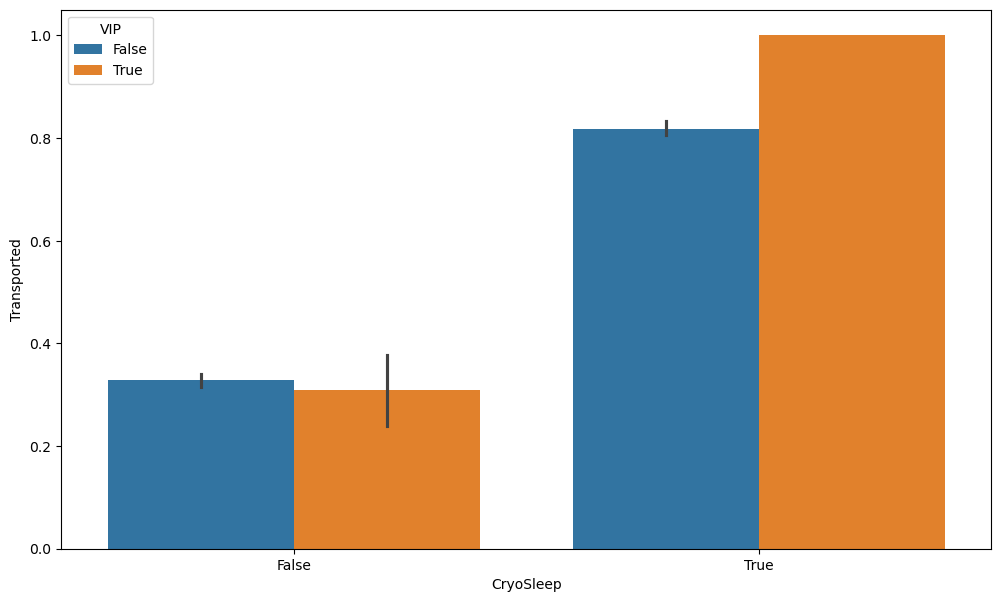

In [10]:
# 동면(CryoSleep)과 VIP 여부가 생존에 미치는 영향 확인

plt.figure(figsize=(12,7))

# sns.barplot: 막대그래프 
# x="CryoSleep" : 가로축을 동면 여부(True/False)로
# y="Transported" : 세로축을 수송된 비율(기본적으로 평균을 내줌)로
# hue="VIP" : 색상을 VIP 여부에 따라 다르게 칠해서 한 번에 3가지 변수를 비교
sns.barplot(x="CryoSleep", y="Transported", hue="VIP" , data= data)

plt.show()
# 이 그래프를 띄워보면 동면(CryoSleep=True)을 한 사람들은
# VIP든 아니든 수송(생존) 확률이 엄청나게 높은 것을 시각적으로 확인
# 피처 중요도에서 CryoSleep이 최상위권에 나오는 이유

In [11]:
# 현재 구멍(결측치)이 얼마나 남았나 확인

# 앞선 단계에서 피처들을 쪼개고 합치는 등 데이터 구조를 건드렸기 때문에, 
# 지금 데이터에 빈칸(NaN)이 몇 개나 있나 찍어보는 함수
data.isna().sum()

# 모델은 빈칸을 보면 에러를 뱉고 죽어버림
# 여기서 HomePlanet, Destination, Cabin 등에 결측치가 수백 개씩 있는 것을 확인하고, 
# 최빈값이나 중간값으로 메워줘야겠다는 다음 단계의 '작업 계획'을 세우기 위해 출력

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

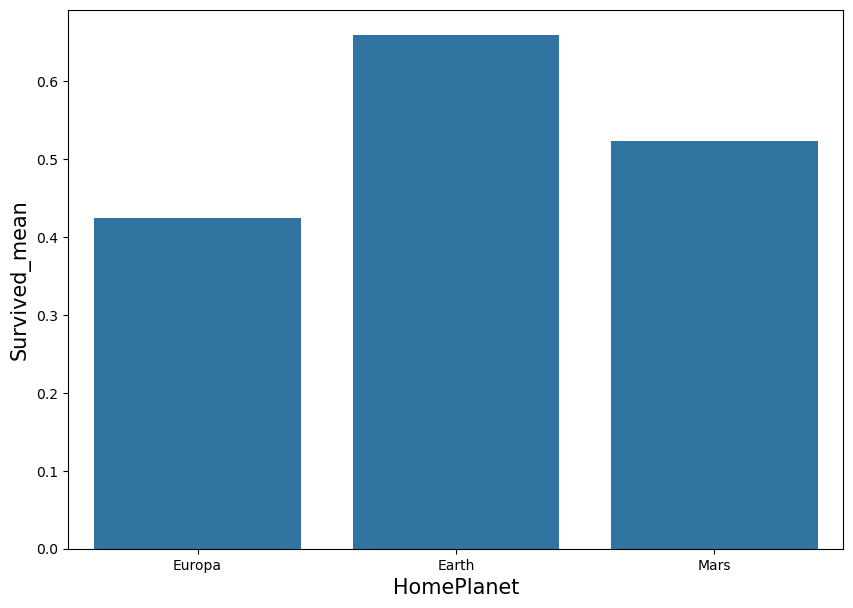

In [12]:
# 출발 행성(HomePlanet)별 수송률 정확하게 확인
    
plt.figure(figsize=(10,7))

# .groupby("HomePlanet") : 데이터를 출발 행성별(지구, 유로파, 화성)로 그룹지어 묶음
# ["Transported"].mean() : 묶인 그룹별로 수송(Transported)된 사람의 '평균(비율)' 계산
# .values : 계산된 비율 '숫자 값'들만 배열 형태로
home_planet_means = data.groupby("HomePlanet")["Transported"].mean().values

# x축에는 행성 이름을 직접 적어주고
# y축에는 방금 계산한 비율(home_planet_means)을 넣어서 막대그래프를 그림
sns.barplot(x=['Europa', 'Earth', 'Mars'], y=home_planet_means)

plt.xlabel("HomePlanet", fontsize=15)
plt.ylabel("Survived_mean", fontsize=15)
plt.show()

# 유로파(Europa) 출신들의 생존율이 압도적으로 높고 지구(Earth) 출신은 낮다는 걸 수치 정확히 확인
# "고향 행성이 생존을 결정짓는 엄청난 힌트가 되겠다!"를 확인하는 과정

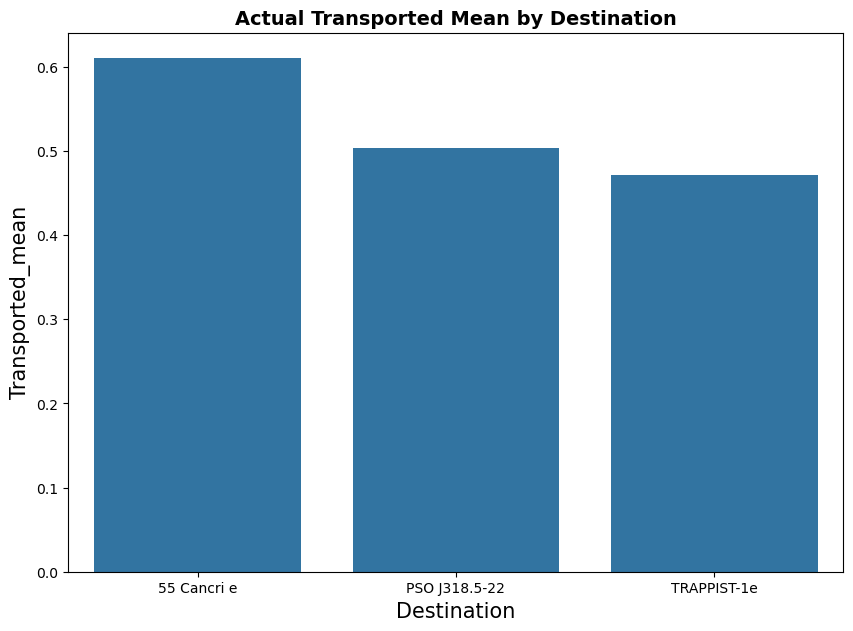

In [13]:
# 목적지(Destination)별 평균 수송률 확인

plt.figure(figsize=(10, 7))

# 출발 행성과 똑같이 계산하되, .sort_index() 추가
# 목적지 이름 알파벳 순서대로(예: 55 Cancri e, PSO J318.5-22, TRAPPIST-1e) 깔끔하게 정렬해서 계산하라는 뜻
dest_means = data.groupby("Destination")["Transported"].mean().sort_index()

# x축에는 목적지 이름들(dest_means.index)을,
# y축에는 계산된 비율 값들(dest_means.values)을 넣음
sns.barplot(x=dest_means.index, y=dest_means.values)

plt.xlabel("Destination", fontsize=15)
plt.ylabel("Transported_mean", fontsize=15)
plt.title("Actual Transported Mean by Destination", fontweight='bold', fontsize=14)
plt.show()

# "55 Cancri e 행성으로 가던 사람들의 수송률이 유독 높은 것을 확인
# 이렇게 확인된 글자 데이터(목적지, 출발지 등)는 나중에 모델이 읽을 수 있게 원-핫 인코딩(0과 1)으로 바꿔줌

### 3. 전처리 (결측치 채우기 및 스케일링/인코딩), 피처 엔지니어링

In [14]:
# 성씨(LastName)와 가족 수(FamilySize) 추출
# 승객 이름 John Smith에서 띄어쓰기를 기준으로 자른 뒤(split), 맨 뒤에 있는 단어([-1])인 Smith만 가져옴
data['LastName'] = data['Name'].str.split().str[-1]

# 같은 성씨를 가진 사람이 몇 명인지 세어서(value_counts) 'FamilySize'라는 파생 변수를 만듬
family_sizes = data['LastName'].value_counts()
data['FamilySize'] = data['LastName'].map(family_sizes)
data['FamilySize'].fillna(1, inplace=True) # 이름이 없던 결측치는 혼자 온 사람(1명)으로 처리
data.drop('LastName', axis=1, inplace=True) # 이름은 이제 다 빼먹었으니 모델이 헷갈리지 않게 휴지통

data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,FamilySize
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,1.0
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,4.0
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,6.0
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,6.0
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,6.0


In [15]:
data.drop("Name", axis=1, inplace=True)

data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,FamilySize
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,1.0
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,4.0
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,6.0
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,6.0
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,6.0


In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Transported   8693 non-null   bool   
 13  FamilySize    8693 non-null   float64
dtypes: bool(1), float64(7), object(6)
memory usage: 891.5+ KB


In [17]:
data.isna().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Transported       0
FamilySize        0
dtype: int64

In [18]:
# 객실(Cabin) 정보 3등분 하기
# Cabin 값은 "B/0/P" 형태, 이를 슬래시(/) 기준으로 잘라 3개의 독립된 컬럼으로 찢어줌(expand=True)
# Cabin1=객실: 층수(B), Cabin2=방 번호(0), Cabin3=좌현/우현(P)으로 쪼개면 모델이 규칙을 찾기 훨씬 쉬워짐
data[["Cabin1", "Cabin2", "Cabin3"]] = data["Cabin"].str.split("/", expand=True)
data.drop("Cabin", axis=1, inplace=True) # 원본 Cabin은 버림
data.head()

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,FamilySize,Cabin1,Cabin2,Cabin3
0,0001_01,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,1.0,B,0,P
1,0002_01,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,4.0,F,0,S
2,0003_01,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,6.0,A,0,S
3,0003_02,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,6.0,A,0,S
4,0004_01,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,6.0,F,1,S


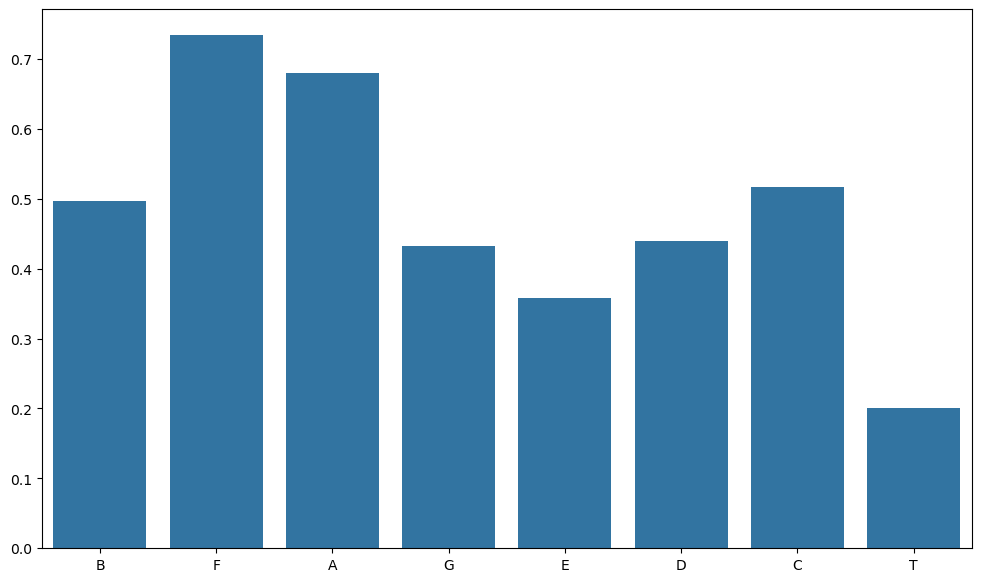

In [19]:
# 객실 구역(Cabin1)별 수송 확률 확인
plt.figure(figsize=(12,7))

# 객실별 수송된 사람의 비율(mean)
cabin_means = data.groupby("Cabin1")["Transported"].mean().values
sns.barplot(x=['B', 'F', 'A', 'G','E', 'D', 'C', 'T'], y=cabin_means)
# 결과 확인: 특정 데크 승객들의 생존율이 압도적으로 높음
plt.show()

In [20]:
# 피처 엔지니어링

# 총 지출 금액(TotalSpending) 만들기
# 부대시설에서 쓴 돈을 전부 더해서 '우주선에서 쓴 총액'이라는 거대한 지표를 하나 만듦
# 돈을 많이 쓴 VIP 여부를 가리기 위함
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
data['TotalSpending'] = data[spending_cols].sum(axis=1)

# 일행 수(GroupSize)와 나홀로 여부(IsAlone) 계산
# PassengerId "0001_01"에서 앞부분("0001")이 그룹 번호
# 언더바(_)로 자르고 앞부분([0])을 가져와 일행 수를 셈
data['Group'] = data['PassengerId'].apply(lambda x: x.split('_')[0])
group_sizes = data['Group'].value_counts()
data['GroupSize'] = data['Group'].map(group_sizes)
data.drop('Group', axis=1, inplace=True) # 임시 변수 삭제

# 일행 수가 1명인 사람들을 True(1), 아니면 False(0)로 만들어서 '혼자 온 사람' 힌트 추가
data['IsAlone'] = (data['GroupSize'] == 1).astype(int)

# 어린이 여부(IsChild) 만들기
# 2단계 그래프에서 12세 이하의 생존율이 높았던 것을 기억하고, 12세 이하면 1, 아니면 0인 전용 변수를 만듦
data['IsChild'] = (data['Age'] <= 12).astype(int)

In [21]:
data["HomePlanet"].fillna("Earth", inplace=True)
data["CryoSleep"].fillna(False, inplace=True)
data["Destination"].fillna('TRAPPIST-1e', inplace=True)

# data["VIP"].value_counts()
data["VIP"].fillna(False, inplace=True)

data = data.dropna(subset=["Cabin1"])

for i in ["Age", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]:
    data[i].fillna(data[i].median(), inplace=True)

data["Cabin2"] = data["Cabin2"].astype("int")

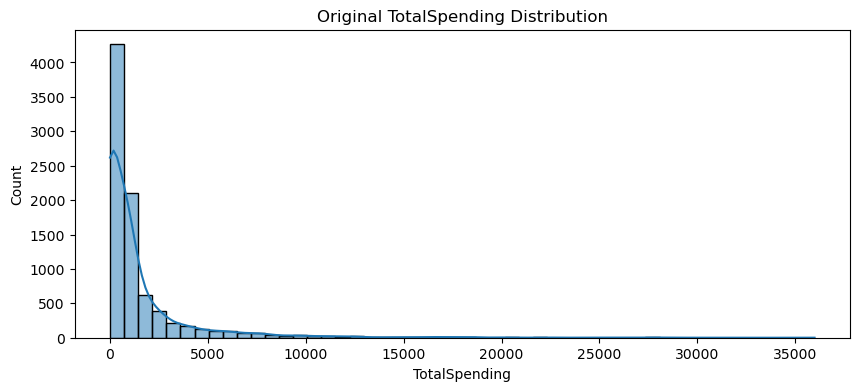

In [22]:
# 수치형 데이터의 분포 형태와 쏠림 현상(왜도) 확인
plt.figure(figsize=(10, 4))
# sns.histplot: 데이터가 어떤 모양으로 퍼져 있는지 '산(Mountain) 모양'으로
sns.histplot(data=data, x='TotalSpending', kde=True, bins=50)
plt.title('Original TotalSpending Distribution')

plt.show()

# 화면에 뜬 그래프를 보면 막대가 왼쪽(0원 쓴 사람들)에 거대한 절벽처럼 쌓여 있고, 
# 오른쪽(돈을 1만 달러, 2만 달러 쓴 소수)으로는 아주 길고 얇게 꼬리가 늘어져 있음.
# 머신러닝 모델은 이렇게 데이터가 한쪽으로 극단적으로 쏠린(왜도가 심한) 상태를 보면 학습할 때 매우 헷갈려함

In [23]:
# 쏠림(왜도) 형상 완화, 로그 변환

# 돈을 쓴 항목들만 모아서 리스트로
log_spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpending']


for col in log_spending_cols: # 만약 우리 데이터에 그 컬럼이 존재한다면 np.log1p() 함수 씌움
    if col in data.columns:
        data[col] = np.log1p(data[col]) # 로그(log)는 10,000을 4로, 1,000을 3으로 줄여버리는 수학 기호
        # 뒤에 붙은 1p(1 plus)는 '0원을 쓴 사람'의 경우 log(0)이 되어 에러가 나는 것을 막기 위해
        # 모든 값에 1을 더한 뒤 로그를 씌우라는 뜻

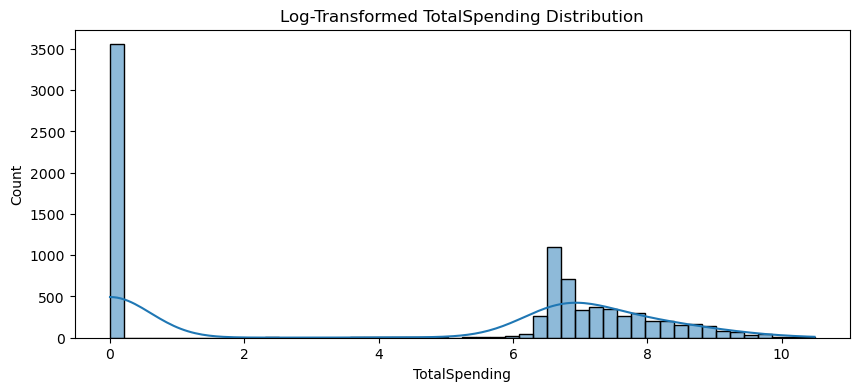

In [24]:
# 수치형 데이터의 분포 형태와 쏠림 현상(왜도) 완화 확인
plt.figure(figsize=(10, 4))
sns.histplot(data=data, x='TotalSpending', kde=True, bins=50)
plt.title('Log-Transformed TotalSpending Distribution')

plt.show()

# 다시 띄워진 그래프를 보면, 왼쪽으로 심하게 쏠려있던 절벽이 
# 부드럽게 둥글둥글한 언덕 모양(정규분포에 가깝게)으로 펴짐
# 이제 모델은 튀는 값에 놀라지 않고, 돈을 쓴 패턴을 편안하고 정확하게 공부할 수 있음

In [25]:
# 글자를 숫자로 쪼개기 (원-핫 인코딩)
# 모델은 'Earth', 'Mars'를 읽지 못함 
# get_dummies를 쓰면 'is_Earth=1, is_Mars=0' 처럼 변수를 쪼개어 컴퓨터가 읽을 수 있는 0과 1로 번역
data = pd.get_dummies(data, columns=['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Cabin1', 'Cabin3'], drop_first=True)

In [26]:
# 인코딩이 완료된 data를 안전하게 복사
encoded_data = data.copy()

# 시각화 가독성을 위해 PassengerId 컬럼이 있다면 제외
if 'PassengerId' in encoded_data.columns:
    encoded_data = encoded_data.drop("PassengerId", axis=1)

# 정답(Transported) 컬럼을 부동소수점이 아닌 정수(0, 1)로 변환
encoded_data['Transported'] = encoded_data['Transported'].astype(int)

# 전체 컬럼에 대한 상관계수 계산
full_corr = encoded_data.corr()

# 히트맵으로 해보려다가 너무 많아서 정렬로 바꿈
# Transported와의 상관계수 절대값을 구한 뒤, 가장 높은 순으로 정렬
top_correlations = full_corr['Transported'].abs().sort_values(ascending=False)

# 상위 15개 피처
print("Transported와 상관계수 상위 15개:")
print(top_correlations.head(15))

Transported와 상관계수 상위 15개:
Transported          1.000000
TotalSpending        0.468160
CryoSleep_True       0.459200
Spa                  0.361031
RoomService          0.354922
VRDeck               0.338770
ShoppingMall         0.178462
HomePlanet_Europa    0.176303
Cabin1_B             0.146571
FoodCourt            0.133483
IsChild              0.127858
IsAlone              0.113773
Cabin1_C             0.109558
Cabin3_S             0.103775
Cabin1_E             0.099254
Name: Transported, dtype: float64


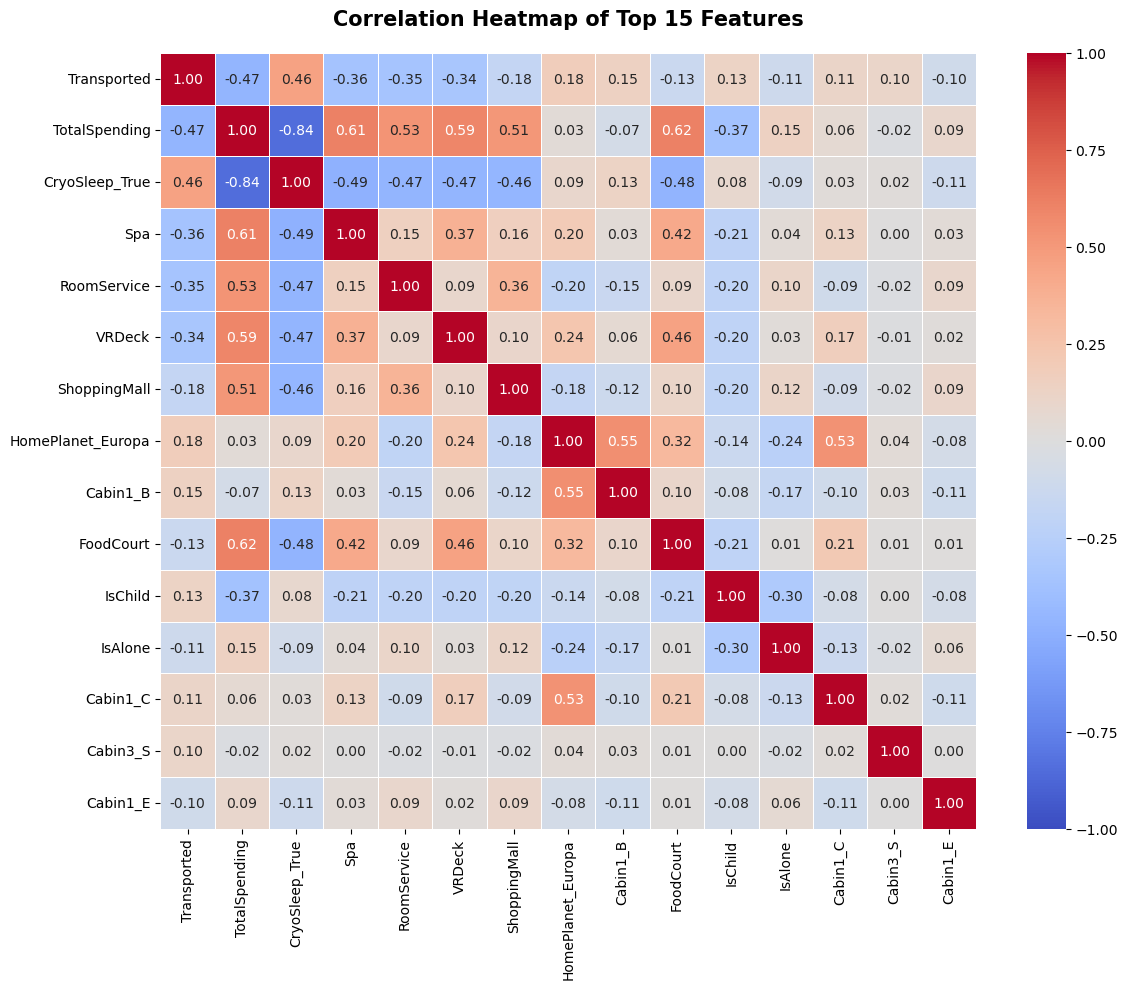

In [27]:
plt.figure(figsize=(12, 10))

# 정렬 순서(top_correlations.head(15).index)대로 full_corr에서 칸을 골라내어 그림
sns.heatmap(full_corr.loc[top_correlations.head(15).index, top_correlations.head(15).index], 
            annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

plt.title('Correlation Heatmap of Top 15 Features', fontweight='bold', fontsize=15, pad=20)
plt.tight_layout()
plt.show()

### 4. Modeling & 튜닝: 모의고사 세팅(쪼개기) 및 인공지능 학습

In [28]:
# 문제집(x)과 정답지(y) 분리하기
# PassengerId는 단순 번호표라 예측에 방해되니 지우고, Transported(정답)는 y로 빼냄
x = data.drop(["PassengerId", "Transported"], axis=1)
y = data["Transported"]

# Train / Test(Validation) 분리
# 모의고사 점수를 확인하기 위해 전체 문제집을 8(공부용):2(모의고사용) 비율로 쪼갬
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

# 모델 선언 및 하이퍼파라미터 튜닝 기계 세팅
model_lgb = lgb.LGBMClassifier() # LightGBM이라는 이름의 똑똑한 분류 모델 호출

In [29]:
# 모델이 공부할 때 적용할 수 있는 수만 가지 설정(옵션)들의 후보군

params_lgb = {
    "n_estimators": [100, 500, 1000], # tree numbers # 나무를 몇 개나 심어서 숲을 만들 것인가?
    "learning_rate": [0.01, 0.05, 0.1, 0.3], # learning rate # 진도를 얼마나 빨리 나갈 것인가? (너무 빠르면 디테일을 놓침)
    "lambda_l1": [0, 10, 20, 30, 50], # L1 규제 (필요 없는 변수를 무시하게 만드는 브레이크)
    "lambda_l2": [0, 10, 20, 30, 50], # L2 규제 (특정 변수에 너무 과몰입하지 않게 만드는 브레이크)
    "max_depth": [5, 10, 15, 20], # max depth of trees # 나무의 가지를 얼마나 깊게 파고들 것인가? (너무 깊으면 과적합 발생)
    "subsample": [0.6, 0.8, 1] # subsmaple rate # 공부할 때 문제집의 몇 %만 뽑아서 볼 것인가?
}

In [ ]:
# RandomizedSearchCV: 이 기계가 후보군 안에서 무작위(Random)로 조합을 뽑아 시험을 쳐보고
# 제일 점수가 높은 조합을 알아서 찾아줌
# scoring="roc_auc": 단순 정확도가 아니라, 분별력(ROC AUC)이 가장 높은 튼튼한 조합을 1등으로 뽑으라는 명령
model_lgb_rs = RandomizedSearchCV(model_lgb, param_distributions=params_lgb, n_iter=30, scoring="roc_auc", n_jobs=-1)

# 학습 시작(fit)
# 80%의 문제집(x_train)과 정답(y_train)을 던져주며 튜닝 기계가 30번(n_iter)의 학습을 시작
model_lgb_rs.fit(x_train, y_train)

#깃허브 파일 업로드 오류나서 해당 셀의 output은 삭제함

In [31]:
# 컴퓨터가 찾은 1등 조합 확인
model_lgb_rs.best_params_

{'subsample': 1,
 'n_estimators': 100,
 'max_depth': 20,
 'learning_rate': 0.05,
 'lambda_l2': 0,
 'lambda_l1': 0}

### 5. 평가(Evaluation) 및 피처 중요도: 성적 확인 및 오답 노트

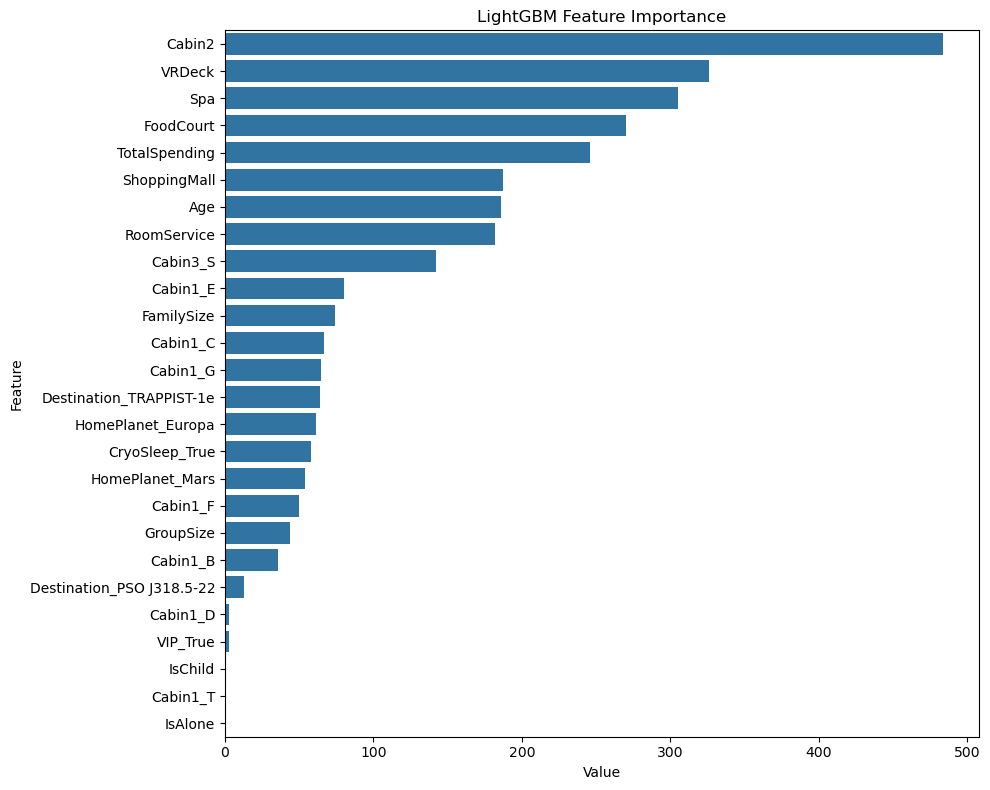

In [32]:
# LightGBM 모델이 어떤 변수를 가장 중요하게 생각하고, 어떤 변수를 쓸모없다고 생각하는지

# 최적의 파라미터로 학습된 최종 LightGBM 모델 가져오기
best_model = model_lgb_rs.best_estimator_

# 중요도 데이터프레임 만들기
feature_imp = pd.DataFrame(sorted(zip(best_model.feature_importances_, x.columns)), columns=['Value','Feature'])

# 시각화
plt.figure(figsize=(10, 8))
sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False))
plt.title('LightGBM Feature Importance')
plt.tight_layout()
plt.show()

In [33]:
from sklearn.metrics import accuracy_score

# 공부한 문제집(x_train)을 다시 풀게 해서 점수 내기
pred_train = model_lgb_rs.predict(x_train)
train_acc = accuracy_score(y_train, pred_train)

# 처음 보는 모의고사(x_test)를 풀게 해서 점수 내기
pred_test = model_lgb_rs.predict(x_test)
test_acc = accuracy_score(y_test, pred_test)

print(f"훈련 세트 정확도 (Train Accuracy) : {train_acc:.4f}")
print(f"시험 세트 정확도 (Test Accuracy)  : {test_acc:.4f}")
print(f"ROC AUC  : {model_lgb_rs.score(x_test, y_test):.4f}")

[LightGBM] [Warning] lambda_l2 is set=0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0
[LightGBM] [Warning] lambda_l1 is set=0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0
[LightGBM] [Warning] lambda_l2 is set=0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0
[LightGBM] [Warning] lambda_l1 is set=0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0
훈련 세트 정확도 (Train Accuracy) : 0.8603
시험 세트 정확도 (Test Accuracy)  : 0.8058
[LightGBM] [Warning] lambda_l2 is set=0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0
[LightGBM] [Warning] lambda_l1 is set=0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0
ROC AUC  : 0.9023


### 6. Test & Submission: 진짜 시험(Test) 풀고 결과 제출

In [34]:
# 정답 없는 시험지(test.csv) 불러오기
test_data = pd.read_csv(join(data_dir, 'test.csv'))

test_data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [35]:
# Train과 완벽하게 똑같이 전처리 및 피처 엔지니어링 수행 (주석 생략 - 위와 100% 동일한 로직)
test_data[["Cabin1", "Cabin2", "Cabin3"]] = test_data["Cabin"].str.split("/", expand=True)
test_data['LastName'] = test_data['Name'].str.split().str[-1]
family_sizes_test = test_data['LastName'].value_counts()
test_data['FamilySize'] = test_data['LastName'].map(family_sizes_test)
test_data['FamilySize'].fillna(1, inplace=True)
test_data.drop(['Name','LastName','Cabin'], axis=1, inplace=True)

In [36]:
for i in ["Age", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]:
  test_data[i].fillna(test_data[i].median(), inplace=True)

In [37]:
# 문자형 결측치 채우기 및 기타 변수 생성
test_data["VIP"].fillna(False, inplace=True)
test_data["HomePlanet"].fillna("Earth", inplace=True)
test_data["Destination"].fillna("TRAPPIST-1e", inplace=True)
test_data["CryoSleep"].fillna(False, inplace=True)
test_data["Cabin1"].fillna("F", inplace=True)

# Cabin3은 객실의 '좌현(P)'인지 '우현(S)'인지를 나타내는 글자
# 빈칸인 사람들은 P나 S 중 하나로 채워야 하므로 임의로 "P"를 지정해 메워줌
test_data["Cabin3"].fillna("P", inplace=True)

# Cabin2 (방 번호) 데이터의 안전한 형변환
# [역할] "123" 처럼 글자(문자열) 취급을 받고 있는 방 번호를, 
# 진짜 수학적 계산이 가능한 숫자(Numeric)로 바꿔주는 코드

# [errors="coerce"가 필요한 이유]
# 실전 데이터에는 방 번호에 실수로 "123A"나 "?" 같은 이상한 문자가 섞여 있을 수 있음
# 만약 errors 옵션이 없다면 컴퓨터는 "이거 숫자로 못 바꿔!" 하고 에러를 뿜으며 코드를 멈춤
# 하지만 errors="coerce"를 주면, 바꿀 수 없는 이상한 문자는
# 강제로 다시 빈칸(NaN)으로 돌려놓으라고 명령하는 방어막 역할
test_data["Cabin2"] = pd.to_numeric(test_data["Cabin2"], errors="coerce")

# Cabin2 (방 번호) 빈칸 채우기
# 위에서 이상한 글자를 빈칸(NaN)으로 바꾼 것까지 포함해서, 이제 최종적으로 방 번호의 빈칸을 메움
# .median() 함수를 써서 전체 승객들의 방 번호들을 쭉 세워놓고 '가장 중간에 있는 번호'를 찾음
# 방 번호가 없다고 0으로 채우는 것보다, 남들이 가장 많이 쓰는 평균적인 중간 번호로 채워 넣는 것이 
# 인공지능이 튀는 값에 혼란스러워하지 않고 학습하기에 훨씬 좋은 정석적인 방법
test_data["Cabin2"].fillna(test_data["Cabin2"].median(), inplace=True)

In [38]:
test_data

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Cabin1,Cabin2,Cabin3,FamilySize
0,0013_01,Earth,True,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,G,3.0,S,4.0
1,0018_01,Earth,False,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,F,4.0,S,1.0
2,0019_01,Europa,True,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,C,0.0,S,1.0
3,0021_01,Europa,False,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,C,1.0,S,1.0
4,0023_01,Earth,False,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,F,5.0,S,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4272,9266_02,Earth,True,TRAPPIST-1e,34.0,False,0.0,0.0,0.0,0.0,0.0,G,1496.0,S,4.0
4273,9269_01,Earth,False,TRAPPIST-1e,42.0,False,0.0,847.0,17.0,10.0,144.0,F,442.0,P,2.0
4274,9271_01,Mars,True,55 Cancri e,26.0,False,0.0,0.0,0.0,0.0,0.0,D,296.0,P,4.0
4275,9273_01,Europa,False,TRAPPIST-1e,26.0,False,0.0,2680.0,0.0,0.0,523.0,D,297.0,P,5.0


In [39]:
# 지출 합계 및 로그 변환
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
test_data['TotalSpending'] = test_data[spending_cols].sum(axis=1)

# 그룹 수 및 파생 변수
test_data['Group'] = test_data['PassengerId'].apply(lambda x: x.split('_')[0])
group_sizes_test = test_data['Group'].value_counts()
test_data['GroupSize'] = test_data['Group'].map(group_sizes_test)
test_data.drop('Group', axis=1, inplace=True) # 임시 변수 삭제
test_data['IsAlone'] = (test_data['GroupSize'] == 1).astype(int)
test_data['IsChild'] = (test_data['Age'] <= 12).astype(int)

log_spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpending']
for col in log_spending_cols:
    if col in test_data.columns:
        test_data[col] = np.log1p(test_data[col])

In [40]:
# 원-핫 인코딩
test_data = pd.get_dummies(test_data, columns=['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Cabin1', 'Cabin3'], drop_first=True)
test_data["Cabin2"] = test_data["Cabin2"].astype("int")

In [41]:
# 모델에게 풀게 할 시험지(x_test_final) 최종 정리
x_test = test_data.drop("PassengerId", axis=1)

# [중요 안전장치] Train 데이터(x)와 Test 데이터의 컬럼 순서나 개수가 다르면 에러가 남
# reindex를 통해 무조건 학습할 때 썼던 컬럼 구조(x.columns)와 똑같이 맞추고, 없는 건 0으로 채워 강제 정렬
x_test = x_test.reindex(columns=x.columns, fill_value=0)

In [42]:
# 실전 문제 풀기 (predict)
# 튜닝해서 똑똑해진 모델에게 진짜 시험지를 던져주고 답을 요청
pred_test = model_lgb_rs.predict(x_test)

[LightGBM] [Warning] lambda_l2 is set=0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0
[LightGBM] [Warning] lambda_l1 is set=0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0


In [43]:
# 제출용 답안지(submission.csv) 만들기
test_data["Transported"] = pred_test # 모델이 찍은 답을 데이터프레임에 붙여넣음
submission = test_data[["PassengerId", "Transported"]] # 문제에서 요구하는 두 개의 컬럼
submission.to_csv("submission.csv", index=False) # 엑셀 파일(csv)로 저장, 이 파일을 캐글에 제출

### 마무리

**베이스라인으로 사용한 코드**
https://www.kaggle.com/code/aieducation/spaceship-titanic-eda-lightgbm-score-80-0

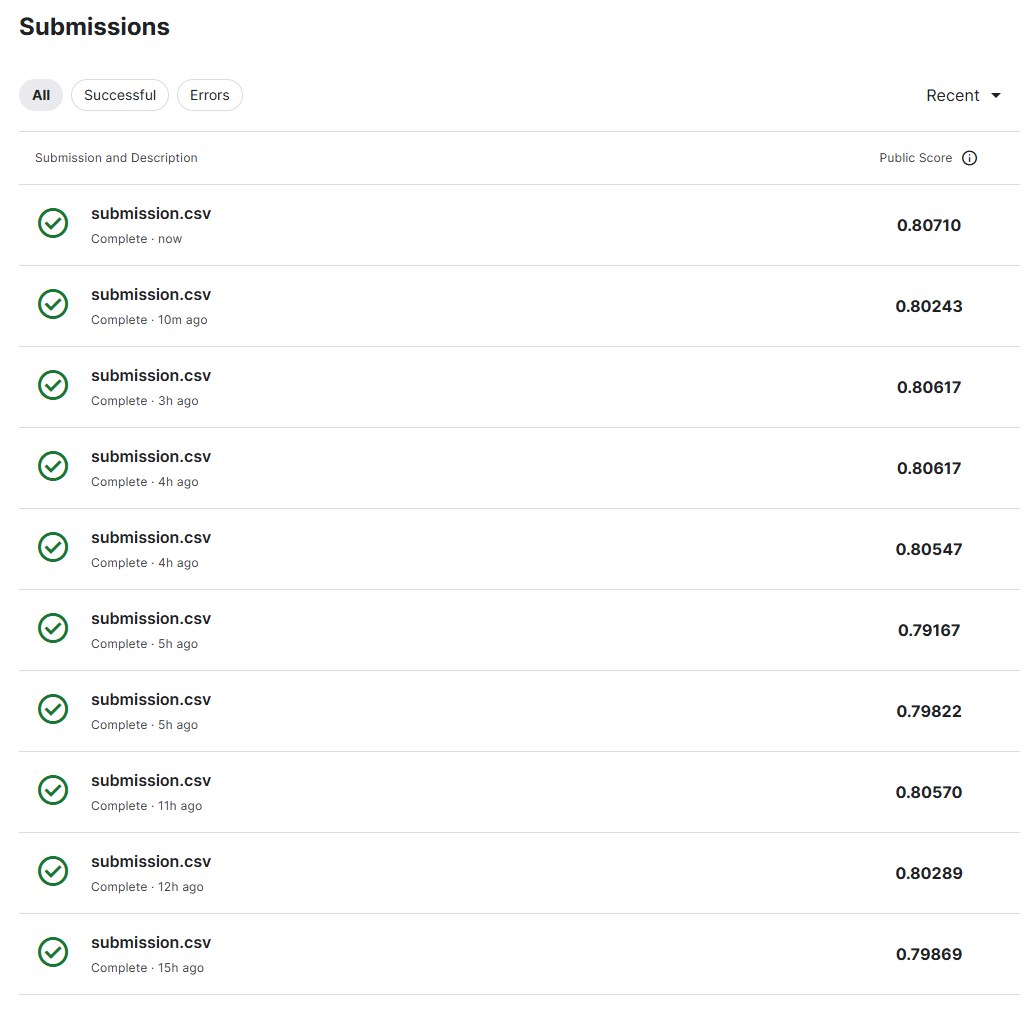

**회고**
- 아직 흐름을 파악하고 필요한 함수나 기능 활용을 자연스럽게 하는 건 거의 불가능해서 검색 뿐만 아니라 AI의 도움을 많이 받았다. 내가 하고 있는게 적합한 지도 판단이 어렵기도 해서 넣었다 뺐다 고쳤다 되돌렸다를 정말 많이 했는데 결론적으로는 기준 점수는 넘어서 멈췄다. 사용은 했지만 이해가 안 가거나 개선하면 좋을 부분이 많고, 다만 아직 이해가 부족하니 막 고치기에는 코드가 오히려 망가질 것 같고 너무 오래 붙잡고 있던 것 같다. 일단은 다시 공부를 하기 위해 주석을 최대한 적고 마무리 했다. 아직 너무 어렵다...
  
- 대략적인 순서
    1. 캐글 코드탭에서 최대한 복잡하지 않고 심플한 코드를 가져와 베이스라인으로 사용
    2. 기존 코드를 내 환경에 맞게 수정 후 코드로 데이터셋 확인
    3. 시각화 활용이 필요해 보이는 부분 그래프 사용
    4. 피처 엔지니어링, 하이퍼 파라미터 등 내가 시도해 볼 수 있는 난이도 정도만 최대한 따라서 진행
    5. 코드 순서 및 주석 정리